# Decoding Strategies

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import pandas as pd

In [3]:
def softmax_(x):
    x= np.array(x)
    x=x-max(x)
    exp_x=np.exp(x)
    return exp_x/sum(exp_x)

In [4]:
def argmax_(val):
    for x in range(len(val)):
        if np.max(val)==val[x]:
            return x

## Exp - 1

In [5]:
logits = np.random.rand(50)
probs = softmax_(logits)
np.argmax(probs)

np.int64(44)

In [6]:
def argmax(ar):
    for x in range(len(ar)):
        if np.max(ar)==ar[x]:
            return x

argmax(probs)

44

In [7]:
c=0
for x in range(10000):
    vals = np.random.rand(500)
    if np.argmax(vals)!=argmax(vals):
        c+=1
if c==0:
    print("Argmax Function Works.")

Argmax Function Works.


## Exp - 2

In [8]:
with open('fake_vocab.json') as f:
    vocab = json.load(f)

In [9]:
def temperature_softmax(logits, T=1.0):
    logits = np.array(logits, dtype=float)
    logits = logits/T
    logits = logits - max(logits)
    exp_logits = np.exp(logits)
    return exp_logits/sum(exp_logits)

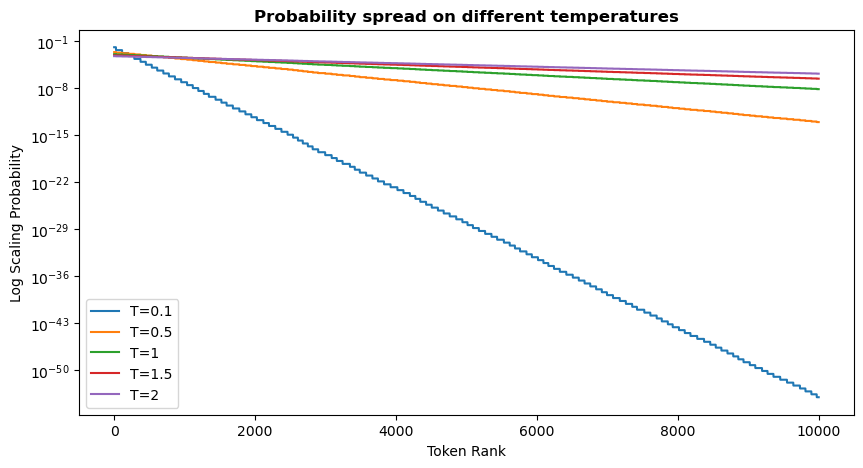

In [10]:
plt.figure(figsize=(10,5))
s=[0.1, 0.5, 1, 1.5, 2]
for temperature in s:
    f = temperature_softmax(list(vocab.values()), T=temperature)
    plt.plot(sorted((f), reverse=True), label=f"T={temperature}")

plt.title("Probability spread on different temperatures", fontweight='bold')
plt.ylabel("Log Scaling Probability")
plt.xlabel("Token Rank")
plt.yscale("log")
plt.legend()
plt.savefig('fig_1_Rank_vs_Probability.jpeg', )

## Exp - 3

In [11]:
# Top-k tokens
df = pd.DataFrame(vocab.items(), columns=['Tokens', 'Logits'])
df['Probs'] = softmax_(list(vocab.values()))
df.sort_values(by='Probs', ascending=False)[:10]

,Tokens,Logits,Probs
22,Berlin_22,10.0,0.001217
4941,London_4941,10.0,0.001217
1945,Canada_1945,10.0,0.001217
1877,Mountain_1877,10.0,0.001217
1613,Mango_1613,10.0,0.001217
3502,Berlin_3502,10.0,0.001217
1707,Canberra_1707,10.0,0.001217
6689,Water_6689,10.0,0.001217
7294,Apple_7294,10.0,0.001217
1146,NewYork_1146,10.0,0.001217


## Exp - 4

In [12]:
sorted_df = df.sort_values(by ='Probs', ascending=False)
sorted_df['prob_cumsum'] = sorted_df['Probs'].cumsum()

threshold1=0.5
thres_05_ = sorted_df[sorted_df['prob_cumsum']<=threshold1]
next_token_05_ = sorted_df.iloc[:len(thres_05_)+1]
print(f"Threshold = {threshold1}")
print(f"Total Tokens = {len(next_token_05_)}")
print(f"Tokens from this list:\n{sorted_df['Tokens'][:len(next_token_05_)]}")

print("\n------------------------------------------------------\n")
threshold2=0.8
thres_08_ = sorted_df[sorted_df['prob_cumsum']<=threshold2]
next_token_08_ = sorted_df.iloc[:len(thres_08_)+1]
print(f"Threshold = {threshold2}")
print(f"Total Tokens = {len(next_token_08_)}")
print(f"Tokens from this list:\n{sorted_df['Tokens'][:len(next_token_08_)]}")

print("\n------------------------------------------------------\n")
threshold3=0.9
thres_09_ = sorted_df[sorted_df['prob_cumsum']<=threshold3]
next_token_09_ = sorted_df.iloc[:len(thres_09_)+1]
print(f"Threshold = {threshold3}")
print(f"Total Tokens = {len(next_token_09_)}")
print(f"Tokens from this list:\n{sorted_df['Tokens'][:len(next_token_09_)]}")

Threshold = 0.5
Total Tokens = 575
Tokens from this list:
22          Berlin_22
4941      London_4941
1945      Canada_1945
1877    Mountain_1877
1613       Mango_1613
            ...      
2093       Mango_2093
9812       Delhi_9812
107      Canberra_107
3045      Canada_3045
1021      London_1021
Name: Tokens, Length: 575, dtype: object

------------------------------------------------------

Threshold = 0.8
Total Tokens = 1332
Tokens from this list:
22          Berlin_22
4941      London_4941
1945      Canada_1945
1877    Mountain_1877
1613       Mango_1613
            ...      
7802      Berlin_7802
1777    Mountain_1777
79          Forest_79
9064      Banana_9064
4614       Apple_4614
Name: Tokens, Length: 1332, dtype: object

------------------------------------------------------

Threshold = 0.9
Total Tokens = 1910
Tokens from this list:
22           Berlin_22
4941       London_4941
1945       Canada_1945
1877     Mountain_1877
1613        Mango_1613
             ...      
6928 

## Exp - 5

In [13]:
logits = np.array(list(vocab.values()))
tokens = np.array(list(vocab.keys()))
proba = softmax_(logits)

In [14]:
#Greedy
for x in range(100):
    idx = argmax_(proba)
    print(idx)
    print(tokens[idx])

22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22
22
Berlin_22

In [15]:
#Top-k
store_output_k = {}
for x in range(100):
    top_indices = np.argsort(proba)[-3:]
    top_tokens = tokens[top_indices]

    renormalized_proba = proba[top_indices]/sum(proba[top_indices])
    selected_token = np.random.choice(top_tokens, p=renormalized_proba)

    if selected_token not in store_output_k.keys():
        store_output_k[selected_token] = 1
    else:
        store_output_k[selected_token]+=1

pd.DataFrame(store_output_k.items(), columns=['Tokens', 'Times Chosen']).sort_values(by='Times Chosen', ascending=False)

,Tokens,Times Chosen
1,Delhi_9572,42
0,London_9601,34
2,Berlin_22,24


In [16]:
#Top-p
p = 0.7
proba = softmax_(logits)

store_output_p={}
for x in range(100):
    sorted_indices = np.argsort(proba)[::-1]
    sorted_tokens = tokens[sorted_indices]
    sorted_proba = proba[sorted_indices]

    temp_proba_cum_sum = np.cumsum(sorted_proba)

    mask = temp_proba_cum_sum<=p
    if not np.all(mask):
        mask[np.argmax(~mask)] = True

    selected_indices = sorted_indices[mask]
    renormalized_temp_proba = sorted_proba[mask]/sum(sorted_proba[mask])
    selected_token = np.random.choice(sorted_tokens[mask], p=renormalized_temp_proba)

    if selected_token not in store_output_p.keys():
        store_output_p[selected_token] = 1
    else:
        store_output_p[selected_token]+=1

pd.DataFrame(store_output_p.items(), columns=['Tokens', 'Times Chosen'])

,Tokens,Times Chosen
0,Tokyo_2230,1
1,Berlin_6302,1
2,Orange_3695,2
3,Mango_7753,1
4,Mountain_8037,1
...,...,...
89,Canberra_7807,1
90,Apple_1934,1
91,Water_8549,1
92,River_2356,1


In [17]:
print(np.allclose(sorted_proba, sorted_df["Probs"].to_numpy()))

True


## Autoregressive Generation

In [18]:
with open('fake_tf.json') as f:
    ft = json.load(f)

with open('fake_transformer_1000.json') as f:
    ft_1000 = json.load(f)

starting_words = ["The", "A", "Every", "Some", "This", "That", "One", "Each", "My", "Your"]

In [19]:
def next_logit(prompt):
    return ft[prompt]

def next_logit_1000(prompt):
    return ft_1000[prompt]

In [20]:
# Temperature Decoder
store_outputs_temp={}

for x in range(1000):
    prompt = np.random.choice(starting_words)
    while True:
        if prompt not in ft_1000.keys():
            break

        next_tl = next_logit_1000(prompt)
        tokens = np.array(list(next_tl.keys()))
        logits = np.array(list(next_tl.values()))

        temp_probs = temperature_softmax(logits, T=0.2)

        selected_token = np.random.choice(tokens, p=temp_probs)

        prompt = prompt + " " + selected_token

    if prompt not in store_outputs_temp.keys():
            store_outputs_temp[prompt]=1
    else:
        store_outputs_temp[prompt]+=1

print(prompt)
print(f"Unique Sequences - {len(store_outputs_temp)}")
store_outputs_temp

The quick cat found painting silently <EOS>
Unique Sequences - 20


{'A quick cat found garden happily <EOS>': 88,
 'The quick cat found painting silently <EOS>': 112,
 'This quick cat found book yesterday <EOS>': 53,
 'Every quick cat found house outside <EOS>': 34,
 'Your quick cat found book easily <EOS>': 78,
 'That quick cat found tree today <EOS>': 99,
 'This quick cat found book easily <EOS>': 61,
 'My quick cat found river carefully <EOS>': 47,
 'Some quick cat found painting easily <EOS>': 107,
 'Each quick cat found river carefully <EOS>': 42,
 'One quick cat found book happily <EOS>': 23,
 'One quick cat found book yesterday <EOS>': 33,
 'Each quick cat found bridge today <EOS>': 25,
 'Every quick cat found house quickly <EOS>': 32,
 'Every quick cat found house happily <EOS>': 28,
 'One quick cat found mouse slowly <EOS>': 49,
 'Each quick cat found bridge carefully <EOS>': 26,
 'My quick cat found river yesterday <EOS>': 60,
 'Your quick cat found river outside <EOS>': 1,
 'My quick cat found castle today <EOS>': 2}

In [21]:
# Top-K Decoder
s_o = {}

k=3
for x in range(1000):
    prompt = np.random.choice(starting_words)
    while True:
        if prompt not in ft_1000.keys():
            break

        next_tl = next_logit_1000(prompt)
        tokens = np.array(list(next_tl.keys()))
        logits = np.array(list(next_tl.values()))
        
        proba = softmax_(logits)

        sorted_index = np.argsort(proba)[-k:]

        renormalized_proba = proba[sorted_index]/sum(proba[sorted_index])
        selected_token = np.random.choice(tokens[sorted_index], p=renormalized_proba)

        prompt = prompt + " " + selected_token
    
    if prompt not in s_o.keys():
        s_o[prompt]=1
    else:
        s_o[prompt]+=1

print(prompt)
print(len(s_o))
s_o

That quick cat found tree today <EOS>
54


{'The quick cat found painting silently <EOS>': 43,
 'My quick cat found river yesterday <EOS>': 27,
 'Each quick cat found bridge carefully <EOS>': 25,
 'Each quick cat found river carefully <EOS>': 60,
 'Your quick cat found river outside <EOS>': 24,
 'One quick cat found book yesterday <EOS>': 18,
 'Your quick cat found mouse today <EOS>': 7,
 'That quick cat found tree today <EOS>': 106,
 'Some quick cat found painting easily <EOS>': 77,
 'This quick cat found book easily <EOS>': 27,
 'A quick cat found garden silently <EOS>': 16,
 'My quick cat found painting today <EOS>': 8,
 'A quick cat found garden happily <EOS>': 105,
 'Every quick cat found house quickly <EOS>': 22,
 'The quick cat found painting happily <EOS>': 18,
 'This quick cat found tree silently <EOS>': 20,
 'This quick cat found book yesterday <EOS>': 19,
 'One quick cat found mouse slowly <EOS>': 24,
 'Your quick cat found book easily <EOS>': 59,
 'My quick cat found castle today <EOS>': 25,
 'Each quick cat found b

In [22]:
# Top-P Decoder

threshold_p = 0.9

prompt = np.random.choice(starting_words)
while True:
    if prompt not in ft_1000.keys():
        break

    next_tl = next_logit_1000(prompt)
    tokens = np.array(list(next_tl.keys()))
    logits = np.array(list(next_tl.values()))
    proba = softmax_(logits)

    sorted_index = np.argsort(proba)[::-1]
    sorted_token = tokens[sorted_index]
    sorted_proba = proba[sorted_index]

    mask =  np.cumsum(sorted_proba) <= threshold_p
    if not np.all(mask):
        mask[np.argmax(~mask)] = True

    renormalized_proba = sorted_proba[mask]/sum(sorted_proba[mask])
    selected_token = np.random.choice(sorted_token[mask], p=renormalized_proba)

    prompt = prompt + " " + selected_token

print(prompt)

My quick cat found castle today <EOS>


In [ ]:
# All In One Comparison

store_outputs={
    "Greedy": {}, "Temperature": {}, "Top-k": {}, "Top-p": {}
}
k=3
p=0.95
sizes = []
for x in range(1000):

    prompt = np.random.choice(starting_words)
    prompt_greedy = prompt
    prompt_temp = prompt
    prompt_topk = prompt
    prompt_top_p = prompt

    while True:
        if prompt_greedy not in ft_1000.keys():
            break

        # Greedy
        next_logits = next_logit_1000(prompt_greedy)
        tokens = np.array(list(next_logits.keys()))
        logits = np.array(list(next_logits.values()))
        probs = softmax_(logits)

        max_proba_greedy = argmax_(probs)
        next_token_greedy = tokens[max_proba_greedy]

        prompt_greedy = prompt_greedy + " " + next_token_greedy

    while True:
        if prompt_temp not in ft_1000.keys():
            break

        #Temperature
        next_logits = next_logit_1000(prompt_temp)
        tokens = np.array(list(next_logits.keys()))
        logits = np.array(list(next_logits.values()))
        temp_probs = temperature_softmax(logits, T=0.6)
        selected_token_temp = np.random.choice(tokens, p=temp_probs)

        prompt_temp = prompt_temp + " " + selected_token_temp

    while True:
        if prompt_topk not in ft_1000.keys():
            break

        #Top-K
        next_logits = next_logit_1000(prompt_topk)
        tokens = np.array(list(next_logits.keys()))
        logits = np.array(list(next_logits.values()))
        probs = softmax_(logits)
        sorted_index = np.argsort(probs)[::-1][:k]

        renormalized_proba = probs[sorted_index]/sum(probs[sorted_index])
        selected_token_topk = np.random.choice(tokens[sorted_index], p=renormalized_proba)

        prompt_topk = prompt_topk + " " + selected_token_topk

    while True:
        if prompt_top_p not in ft_1000.keys():
            break

        #Top-p
        next_logits = next_logit_1000(prompt_top_p)
        tokens = np.array(list(next_logits.keys()))
        logits = np.array(list(next_logits.values()))
        probs = softmax_(logits)

        sorted_index_p = np.argsort(probs)[::-1]
        sorted_token = tokens[sorted_index_p]
        sorted_proba = probs[sorted_index_p]

        mask =  np.cumsum(sorted_proba) <= p
        if not np.all(mask):
            mask[np.argmax(~mask)] = True

        sizes.append(mask.sum())

        renormalized_proba_p = sorted_proba[mask]/sum(sorted_proba[mask])
        selected_token_topp = np.random.choice(sorted_token[mask], p=renormalized_proba_p)

        prompt_top_p = prompt_top_p + " " + selected_token_topp
        

    if prompt_greedy not in store_outputs["Greedy"].keys():
            store_outputs["Greedy"][prompt_greedy]=1
    else:
        store_outputs["Greedy"][prompt_greedy]+=1

    if prompt_temp not in store_outputs["Temperature"].keys():
            store_outputs["Temperature"][prompt_temp]=1
    else:
        store_outputs["Temperature"][prompt_temp]+=1
    
    if prompt_topk not in store_outputs["Top-k"].keys():
            store_outputs["Top-k"][prompt_topk]=1
    else:
        store_outputs["Top-k"][prompt_topk]+=1
    
    if prompt_top_p not in store_outputs["Top-p"].keys():
            store_outputs["Top-p"][prompt_top_p]=1
    else:
        store_outputs["Top-p"][prompt_top_p]+=1

print("Sentences\n------------------------------------------------")
for x,y in store_outputs.items():
    print(f"{x} = {len(y)} unique sentences")

print("\nMost Frequent Sentence\n------------------------------------------------")
for key, x in store_outputs['Greedy'].items():
    if x==max(store_outputs['Greedy'].values()):
        print(f"Greedy - {key}")

for key, x in store_outputs['Temperature'].items():
    if x==max(store_outputs['Temperature'].values()):
        print(f"Temperature - {key}")

for key, x in store_outputs['Top-k'].items():
    if x==max(store_outputs['Top-k'].values()):
        print(f"Top-K - {key}")

for key, x in store_outputs['Top-p'].items():
    if x==max(store_outputs['Top-p'].values()):
        print(f"Top-P - {key}")

print("\nEntropy\n------------------------------------------------")
for decoder, output in store_outputs.items():
    counts = np.array(list(output.values()))
    probs = counts/counts.sum()
    se = -np.sum(probs* np.log2(probs))
    print(f"{decoder} = {round(se,4)}")

Sentences
------------------------------------------------
Greedy = 10 unique sentences
Temperature = 46 unique sentences
Top-k = 58 unique sentences
Top-p = 51 unique sentences

Most Frequent Sentence
------------------------------------------------
Greedy - One quick cat found mouse slowly <EOS>
Temperature - A quick cat found garden happily <EOS>
Top-K - A quick cat found garden happily <EOS>
Top-P - That quick cat found tree today <EOS>

Entropy
------------------------------------------------
Greedy = 3.3095
Temperature = 4.6406
Top-k = 4.9896
Top-p = 4.9534
